 Log Transformation , Reciprocal Transformation , Square & square root , custom function Transformation 

In [34]:
import pandas as pd 
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [35]:
df = pd.read_csv('train.csv', usecols=['Age','Fare','Survived'])

In [36]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [38]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [39]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [40]:
X = df.iloc[:,1:3] # independent feature [Age,Fare]
y = df.iloc[:,0] # Dependent feature [Survived]

In [41]:
X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2,random_state=42)

| Function           | Purpose                |
| ------------------ | ---------------------- |
| `sns.histplot()`   | histogram              |
| `sns.kdeplot()`    | density curve          |
| `sns.boxplot()`    | outliers               |
| `sns.violinplot()` | distribution + density |


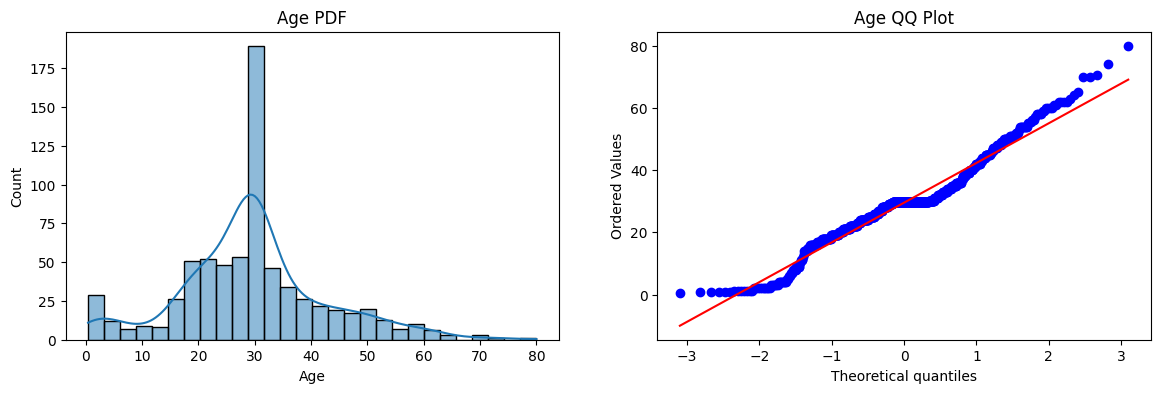

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Age'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

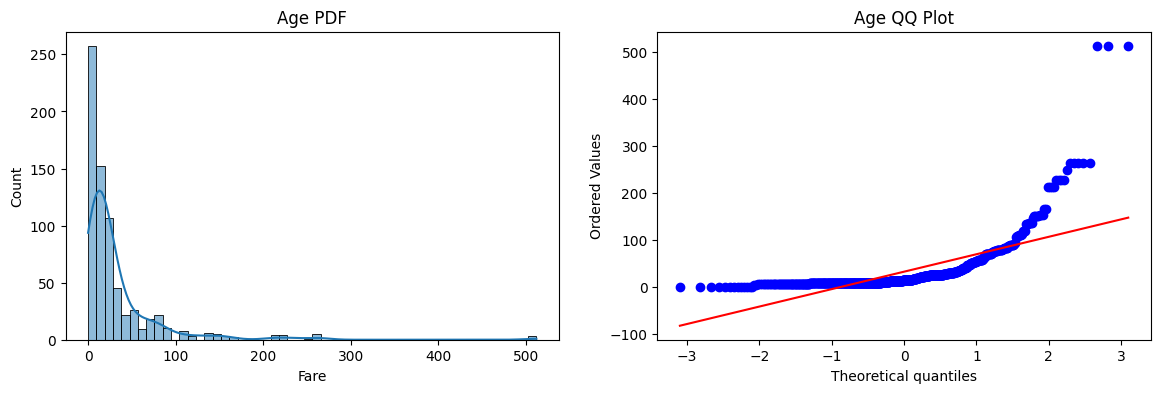

In [43]:
plt.figure(figsize=(14,4))

plt.subplot(121)
sns.histplot(X_train['Fare'], kde=True)
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()

In [44]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [45]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print('Accuracy LR', accuracy_score(y_test,y_pred))
print('Accuracy DT', accuracy_score(y_test,y_pred1))



Accuracy LR 0.6480446927374302
Accuracy DT 0.6703910614525139


In [46]:
trf = FunctionTransformer(func=np.log1p)

In [49]:

X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [50]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)

print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6815642458100558
Accuracy DT 0.6871508379888268
